In [2]:
# CELL 1: Imports
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CELL 2: Load Iris Dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target_names[iris.target], name='species')

# Combine features and target
data = X.copy()
data['species'] = y

print(f"Total samples: {len(data)}")

Total samples: 150


# ID3 ALGORITHM

In [3]:
# CELL 3: Split 80% Train, 20% Validation
train, val = train_test_split(data, test_size=0.2, random_state=42, stratify=data['species'])

print(f"Train samples: {len(train)} (80%)")
print(f"Validation samples: {len(val)} (20%)")

Train samples: 120 (80%)
Validation samples: 30 (20%)


In [4]:
# CELL 4: Create 9 UNSEEN synthetic test samples (NOT from original data)
np.random.seed(123)  # For reproducibility
unseen_test = pd.DataFrame({
    'sepal length (cm)': np.random.uniform(4.3, 7.9, 9),
    'sepal width (cm)': np.random.uniform(2.0, 4.4, 9),
    'petal length (cm)': np.random.uniform(1.0, 6.9, 9),
    'petal width (cm)': np.random.uniform(0.1, 2.5, 9)
})

print("\n9 Unseen Test Samples:")
print(unseen_test.round(2))


9 Unseen Test Samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0               6.81              2.94               4.14              0.65
1               5.33              2.82               4.14              0.80
2               5.12              3.75               4.74              1.61
3               6.28              3.05               6.01              0.32
4               6.89              2.14               5.27              1.14
5               5.82              2.96               4.61              1.13
6               7.83              3.77               5.26              1.28
7               6.77              2.44               2.91              1.12
8               6.03              2.42               3.13              0.85


In [5]:
# CELL 5: ID3 Decision Tree from Scratch

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # column name
        self.threshold = threshold  # split value
        self.left = left
        self.right = right
        self.value = value          # class label if leaf

def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

def information_gain(X, y, feature, threshold):
    left = X[feature] <= threshold
    right = ~left
    y_left, y_right = y[left], y[right]
    
    if len(y_left) == 0 or len(y_right) == 0:
        return 0
    
    n = len(y)
    gain = entropy(y) - (len(y_left)/n * entropy(y_left) + len(y_right)/n * entropy(y_right))
    return gain

def best_split(X, y):
    best_gain = -1
    best_feat = None
    best_thresh = None
    
    for feat in X.columns:
        thresholds = np.unique(X[feat])
        for t in thresholds:
            gain = information_gain(X, y, feat, t)
            if gain > best_gain:
                best_gain = gain
                best_feat = feat
                best_thresh = t
    return best_feat, best_thresh, best_gain

def build_tree(X, y, max_depth=10, depth=0):
    if len(np.unique(y)) == 1:
        return Node(value=y.iloc[0])
    
    if max_depth is not None and depth >= max_depth:
        return Node(value=y.mode().iloc[0])
    
    feat, thresh, gain = best_split(X, y)
    if gain == 0:
        return Node(value=y.mode().iloc[0])
    
    left_mask = X[feat] <= thresh
    left_child = build_tree(X[left_mask], y[left_mask], max_depth, depth+1)
    right_child = build_tree(X[~left_mask], y[~left_mask], max_depth, depth+1)
    
    return Node(feature=feat, threshold=thresh, left=left_child, right=right_child)

def predict_one(tree, sample):
    if tree.value is not None:
        return tree.value
    if sample[tree.feature] <= tree.threshold:
        return predict_one(tree.left, sample)
    else:
        return predict_one(tree.right, sample)

def predict(tree, X):
    return [predict_one(tree, row) for _, row in X.iterrows()]

In [6]:
# CELL 6: Train ID3 on Train Set
X_train = train.drop('species', axis=1)
y_train = train['species']

print("Building ID3 Tree...")
tree = build_tree(X_train, y_train, max_depth=5)

# Predictions
y_train_pred = predict(tree, X_train)
y_val_pred = predict(tree, val.drop('species', axis=1))
y_unseen_pred = predict(tree, unseen_test)

Building ID3 Tree...



=== TRAIN SET ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Confusion Matrix:
[[40  0  0]
 [ 0 40  0]
 [ 0  0 40]]


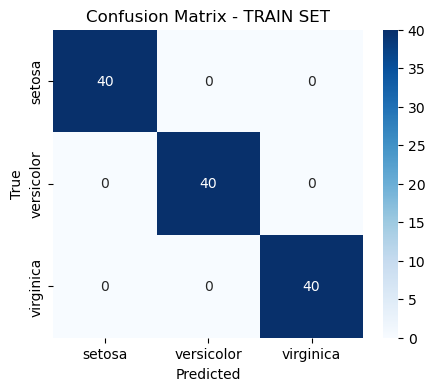


=== VALIDATION SET ===
Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333
F1-Score:  0.9333
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


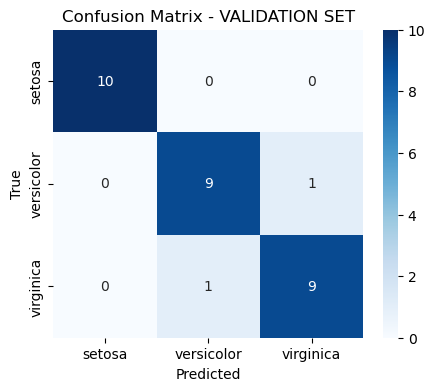

In [7]:
# CELL 7: Evaluation Function
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa', 'versicolor', 'virginica'],
                yticklabels=['setosa', 'versicolor', 'virginica'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# Evaluate Train
evaluate(y_train, y_train_pred, "TRAIN SET")

# Evaluate Validation
evaluate(val['species'], y_val_pred, "VALIDATION SET")

In [8]:
# CELL 8: Predictions on 9 Unseen Samples
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES")
print("="*60)

unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]

print(unseen_results.round(2))


PREDICTIONS ON 9 UNSEEN TEST SAMPLES
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32         virginica  
Sample 5              1.14         virginica  

# RANDOM FOREST


=== TRAIN SET ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
Confusion Matrix:
[[40  0  0]
 [ 0 40  0]
 [ 0  0 40]]


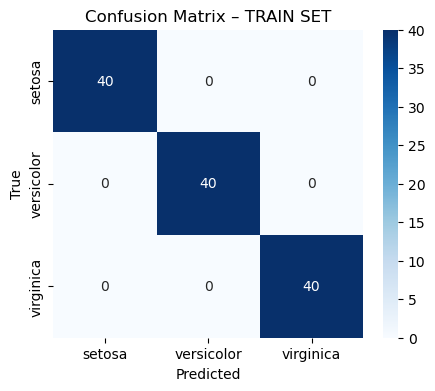


=== VALIDATION SET ===
Accuracy : 0.9000
Precision: 0.9024
Recall   : 0.9000
F1-Score : 0.8997
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


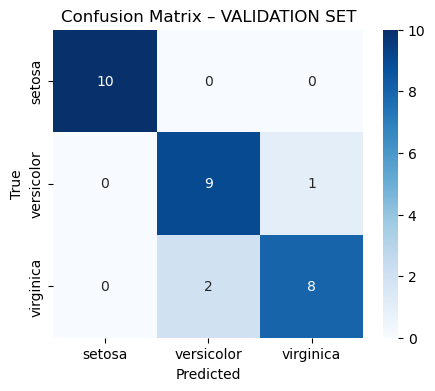


PREDICTIONS ON 9 UNSEEN TEST SAMPLES
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32         virginica  
Sample 5              1.14         virginica  

In [10]:
# --------------------------------------------------------------
# CELL: Random Forest – Train, Evaluate, Predict on unseen test
# --------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare X / y for train & validation
# ------------------------------------------------------------------
X_train = train.drop('species', axis=1)
y_train = train['species']

X_val   = val.drop('species', axis=1)
y_val   = val['species']

# ------------------------------------------------------------------
# 2. Train Random Forest
# ------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ------------------------------------------------------------------
# 3. Helper: evaluation + confusion-matrix plot
# ------------------------------------------------------------------
def evaluate_rf(y_true, y_pred, name):
    acc   = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    cm = confusion_matrix(
        y_true, y_pred,
        labels=['setosa', 'versicolor', 'virginica']
    )
    
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# ------------------------------------------------------------------
# 4. Evaluate on TRAIN
# ------------------------------------------------------------------
y_train_pred = rf.predict(X_train)
evaluate_rf(y_train, y_train_pred, "TRAIN SET")

# ------------------------------------------------------------------
# 5. Evaluate on VALIDATION
# ------------------------------------------------------------------
y_val_pred = rf.predict(X_val)
evaluate_rf(y_val, y_val_pred, "VALIDATION SET")

# ------------------------------------------------------------------
# 6. Predict on the 9 UNSEEN test samples
# ------------------------------------------------------------------
y_unseen_pred = rf.predict(unseen_test)

print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES")
print("="*60)

unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(len(unseen_results))]

print(unseen_results.round(2))

# KNN


=== TRAIN SET (k=3) ===
Accuracy : 0.9750
Precision: 0.9752
Recall   : 0.9750
F1-Score : 0.9750
Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  1 39]]


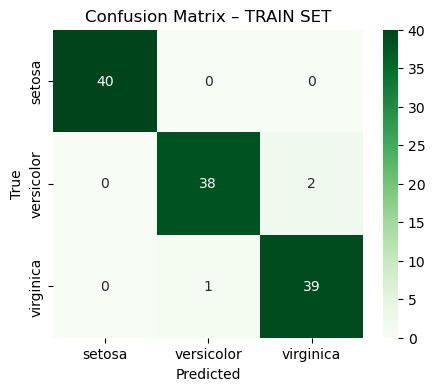


=== VALIDATION SET (k=3) ===
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1-Score : 0.9666
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


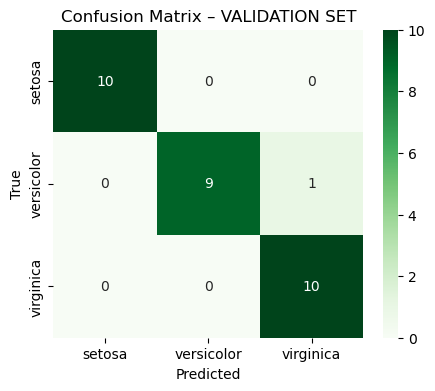


PREDICTIONS ON 9 UNSEEN TEST SAMPLES
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32         virginica  
Sample 5              1.14         virginica  

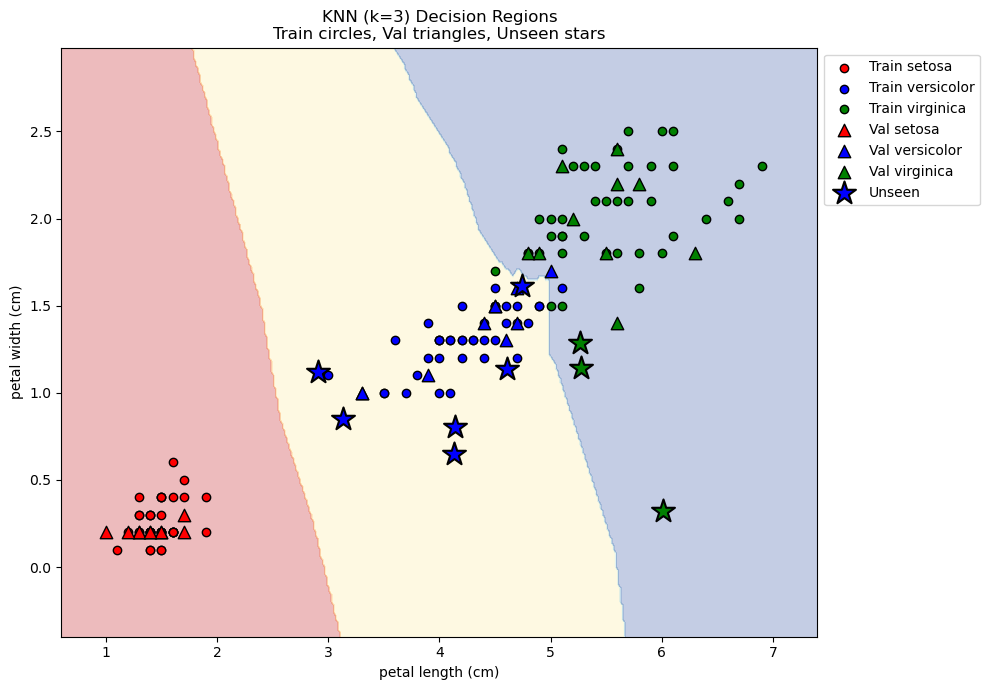

In [11]:
# --------------------------------------------------------------
# CELL: KNN – Train, Evaluate, Plot Regions, Predict on unseen
# --------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 1. Prepare data (keep original DataFrames for later printing)
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1)
y_train      = train['species']
X_val_full   = val.drop('species', axis=1)
y_val        = val['species']

# ---- 2-D subset for visualisation (petal length & width) ----
feat1, feat2 = 'petal length (cm)', 'petal width (cm)'
X_train_2d = X_train_full[[feat1, feat2]].values          # <-- NumPy array
X_val_2d   = X_val_full[[feat1, feat2]].values
unseen_2d  = unseen_test[[feat1, feat2]].values

# ---- Encode string labels to integers (required for contourf) ----
le = LabelEncoder()
le.fit(['setosa', 'versicolor', 'virginica'])
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)

# ------------------------------------------------------------------
# 2. Train KNN (k=5 – change if you like)
# ------------------------------------------------------------------
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_2d, y_train_enc)          # <-- fit on integers

# ------------------------------------------------------------------
# 3. Evaluation helper
# ------------------------------------------------------------------
def evaluate_knn(y_true_enc, y_pred_enc, name):
    # back to original strings for sklearn metrics
    y_true_str = le.inverse_transform(y_true_enc)
    y_pred_str = le.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_true_str, y_pred_str)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_str, y_pred_str, average='weighted'
    )
    cm = confusion_matrix(
        y_true_str, y_pred_str,
        labels=['setosa', 'versicolor', 'virginica']
    )

    print(f"\n=== {name} (k={k}) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# ------------------------------------------------------------------
# 4. Predict & evaluate
# ------------------------------------------------------------------
y_train_pred_enc = knn.predict(X_train_2d)
y_val_pred_enc   = knn.predict(X_val_2d)

evaluate_knn(y_train_enc, y_train_pred_enc, "TRAIN SET")
evaluate_knn(y_val_enc,   y_val_pred_enc,   "VALIDATION SET")

# ------------------------------------------------------------------
# 5. Predict on the 9 unseen samples (return original names)
# ------------------------------------------------------------------
y_unseen_pred_enc = knn.predict(unseen_2d)
y_unseen_pred_str = le.inverse_transform(y_unseen_pred_enc)

print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred_str
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 6. KNN decision-region plot (2-D)
# ------------------------------------------------------------------
def plot_knn_regions():
    h = 0.02                                 # mesh step
    x_min, x_max = X_train_2d[:,0].min()-0.5, X_train_2d[:,0].max()+0.5
    y_min, y_max = X_train_2d[:,1].min()-0.5, X_train_2d[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on mesh – returns integer codes
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10,7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

    # colour map for original class names
    colors = {'setosa':'red', 'versicolor':'blue', 'virginica':'green'}

    # ---- train points (circles) ----
    for cls_name in colors:
        mask = (y_train == cls_name)
        plt.scatter(X_train_2d[mask,0], X_train_2d[mask,1],
                    c=colors[cls_name], label=f'Train {cls_name}',
                    marker='o', edgecolor='k')

    # ---- validation points (triangles) ----
    for cls_name in colors:
        mask = (y_val == cls_name)
        plt.scatter(X_val_2d[mask,0], X_val_2d[mask,1],
                    c=colors[cls_name], marker='^', s=80,
                    edgecolor='k', label=f'Val {cls_name}')

    # ---- unseen test points (stars) ----
    for i, (x, y) in enumerate(unseen_2d):
        pred = y_unseen_pred_str[i]
        plt.scatter(x, y, c=colors[pred], marker='*', s=300,
                    edgecolor='black', linewidth=1.5,
                    label='Unseen' if i==0 else "")

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f'KNN (k={k}) Decision Regions\n'
              'Train circles, Val triangles, Unseen stars')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

# ---- run the plot ----
plot_knn_regions()


=== TRAIN SET (SVM - Full Features) ===
Accuracy : 0.9833
Precision: 0.9833
Recall   : 0.9833
F1-Score : 0.9833
Confusion Matrix:
[[40  0  0]
 [ 0 39  1]
 [ 0  1 39]]


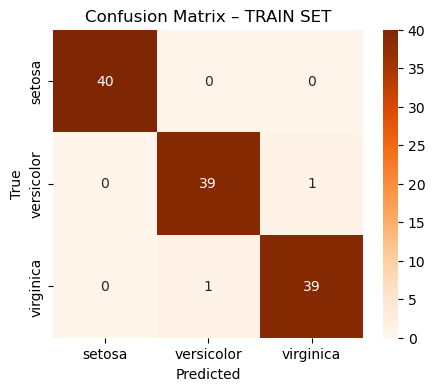


=== VALIDATION SET (SVM - Full Features) ===
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1-Score : 0.9666
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


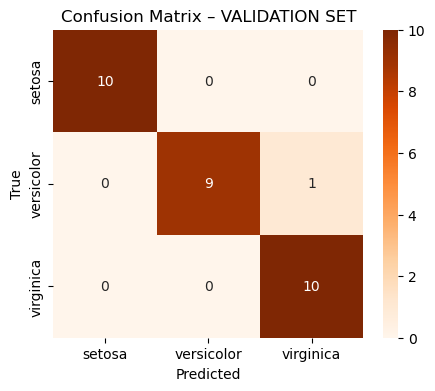


PREDICTIONS ON 9 UNSEEN TEST SAMPLES
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32         virginica  
Sample 5              1.14        versicolor  

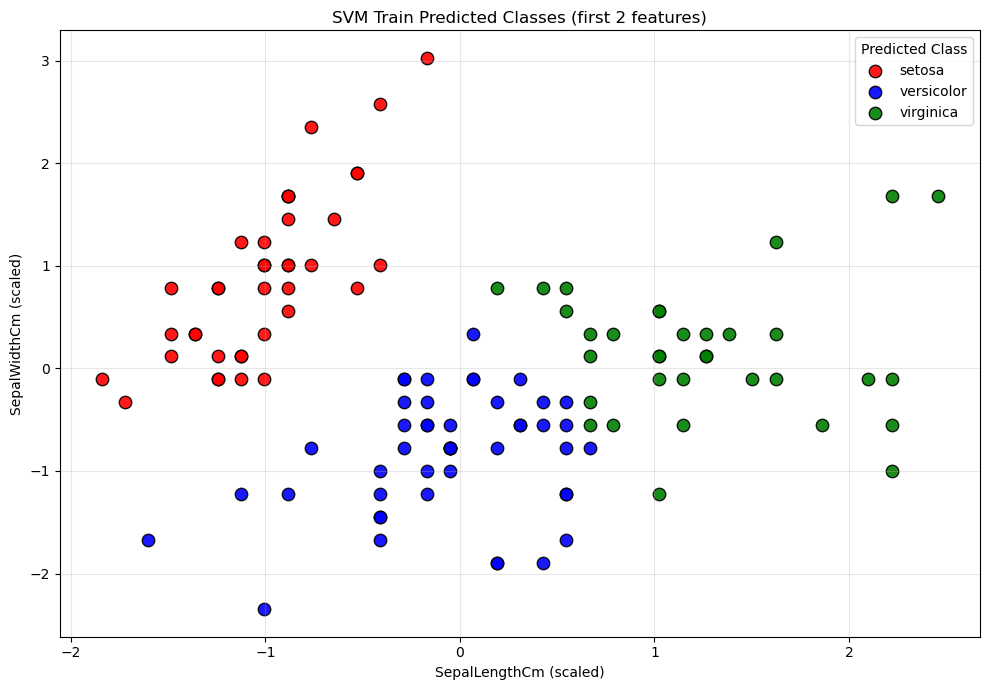

In [13]:
# --------------------------------------------------------------
# CELL: SVM – Metrics + Plot Predicted Classes on Scaled Sepals
# --------------------------------------------------------------

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1)
y_train      = train['species']
X_val_full   = val.drop('species', axis=1)
y_val        = val['species']

# Use only sepal length & sepal width for 2D plot
feat1, feat2 = 'sepal length (cm)', 'sepal width (cm)'
X_train_2d = X_train_full[[feat1, feat2]].values
X_val_2d   = X_val_full[[feat1, feat2]].values
X_unseen_2d = unseen_test[[feat1, feat2]].values

# ------------------------------------------------------------------
# 2. Scale the 2D features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_val_2d_scaled   = scaler.transform(X_val_2d)
X_unseen_2d_scaled = scaler.transform(X_unseen_2d)

# ------------------------------------------------------------------
# 3. Train SVM on FULL data (for accurate metrics)
# ------------------------------------------------------------------
svm_full = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_full.fit(X_train_full, y_train)

y_train_pred_full = svm_full.predict(X_train_full)
y_val_pred_full   = svm_full.predict(X_val_full)

# ------------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------------
def evaluate_svm(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (SVM - Full Features) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_svm(y_train, y_train_pred_full, "TRAIN SET")
evaluate_svm(y_val,   y_val_pred_full,   "VALIDATION SET")

# ------------------------------------------------------------------
# 5. Predict on 9 unseen samples
# ------------------------------------------------------------------
y_unseen_pred = svm_full.predict(unseen_test)

print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 6. PLOT: SVM Train Predicted Classes (Scaled Sepal Length vs Width)
# ------------------------------------------------------------------
# Train a separate SVM on the 2D scaled sepal features to get predicted classes
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train)
y_train_pred_2d = svm_2d.predict(X_train_2d_scaled)

# Color map
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

plt.figure(figsize=(10, 7))
for species in colors:
    mask = (y_train_pred_2d == species)
    plt.scatter(X_train_2d_scaled[mask, 0], X_train_2d_scaled[mask, 1],
                c=colors[species], label=species, s=80, edgecolor='k', alpha=0.9)

plt.xlabel('SepalLengthCm (scaled)')
plt.ylabel('SepalWidthCm (scaled)')
plt.title('SVM Train Predicted Classes (first 2 features)')
plt.legend(title='Predicted Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K MEANS

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



=== TRAIN SET (K-Means) ===
Accuracy : 0.9667
Precision: 0.9674
Recall   : 0.9667
F1-Score : 0.9666
Confusion Matrix:
[[40  0  0]
 [ 0 39  1]
 [ 0  3 37]]


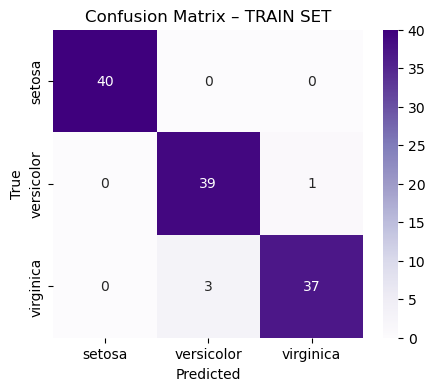


=== VALIDATION SET (K-Means) ===
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1-Score : 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


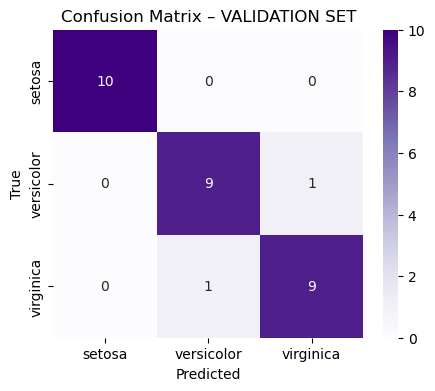


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (K-Means)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32        versicolor  
Sample 5              1.14        ve

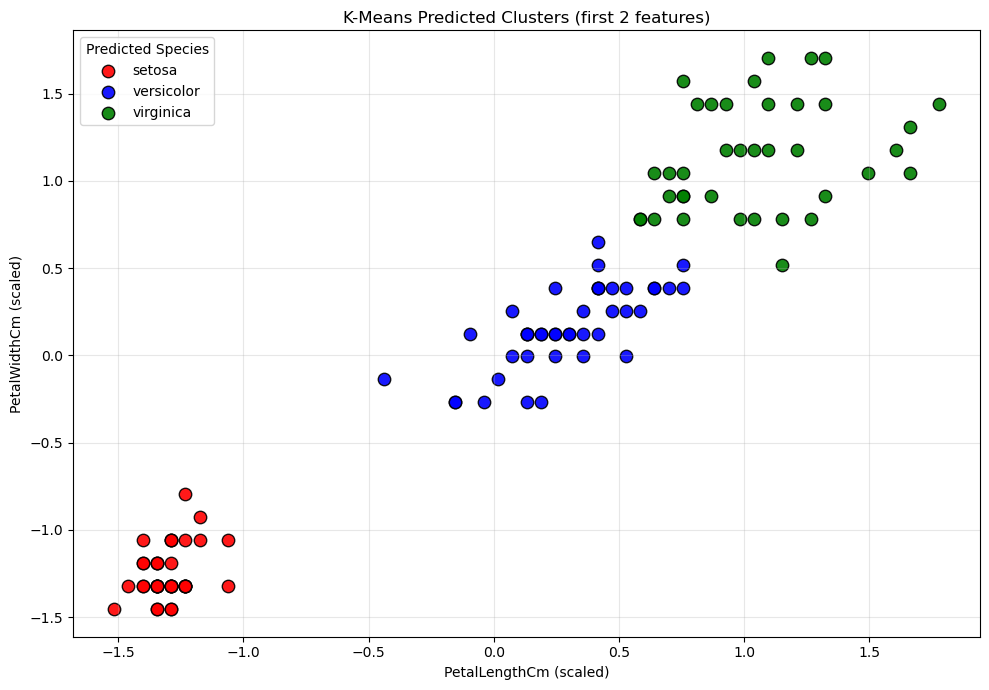

In [14]:
# --------------------------------------------------------------
# CELL: K-Means Clustering – Metrics + Scaled Petal Plot
# --------------------------------------------------------------

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1)
y_train      = train['species']
X_val_full   = val.drop('species', axis=1)
y_val        = val['species']

# Use petal length & petal width for clustering and plotting
feat_x, feat_y = 'petal length (cm)', 'petal width (cm)'
X_train_2d = X_train_full[[feat_x, feat_y]].values
X_val_2d   = X_val_full[[feat_x, feat_y]].values
X_unseen_2d = unseen_test[[feat_x, feat_y]].values

# ------------------------------------------------------------------
# 2. Scale the 2D features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_val_2d_scaled   = scaler.transform(X_val_2d)
X_unseen_2d_scaled = scaler.transform(X_unseen_2d)

# ------------------------------------------------------------------
# 3. Train K-Means on scaled train data
# ------------------------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_train_2d_scaled)

# Predict clusters
train_cluster_labels = kmeans.predict(X_train_2d_scaled)
val_cluster_labels   = kmeans.predict(X_val_2d_scaled)
unseen_cluster_labels = kmeans.predict(X_unseen_2d_scaled)

# ------------------------------------------------------------------
# 4. Map cluster IDs → true species (majority vote in train)
# ------------------------------------------------------------------
cluster_to_species = {}
for cluster_id in range(3):
    mask = (train_cluster_labels == cluster_id)
    if mask.sum() > 0:
        majority_species = y_train[mask].mode()[0]
        cluster_to_species[cluster_id] = majority_species
    else:
        cluster_to_species[cluster_id] = 'unknown'

# Apply mapping
y_train_pred = [cluster_to_species[cl] for cl in train_cluster_labels]
y_val_pred   = [cluster_to_species[cl] for cl in val_cluster_labels]
y_unseen_pred = [cluster_to_species[cl] for cl in unseen_cluster_labels]

# ------------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------------
def evaluate_clustering(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (K-Means) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_clustering(y_train, y_train_pred, "TRAIN SET")
evaluate_clustering(y_val,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 6. Predict on 9 unseen samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (K-Means)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 7. PLOT: K-Means Predicted Clusters (Scaled Petal Length vs Width)
# ------------------------------------------------------------------
# Use the same cluster → species mapping for coloring
cluster_colors = {
    0: 'red' if cluster_to_species[0] == 'setosa' else 
       'blue' if cluster_to_species[0] == 'versicolor' else 'green',
    1: 'red' if cluster_to_species[1] == 'setosa' else 
       'blue' if cluster_to_species[1] == 'versicolor' else 'green',
    2: 'red' if cluster_to_species[2] == 'setosa' else 
       'blue' if cluster_to_species[2] == 'versicolor' else 'green'
}

plt.figure(figsize=(10, 7))
for cluster_id in range(3):
    mask = (train_cluster_labels == cluster_id)
    species_name = cluster_to_species[cluster_id]
    plt.scatter(X_train_2d_scaled[mask, 0], X_train_2d_scaled[mask, 1],
                c=cluster_colors[cluster_id], label=species_name,
                s=80, edgecolor='k', alpha=0.9)

plt.xlabel('PetalLengthCm (scaled)')
plt.ylabel('PetalWidthCm (scaled)')
plt.title('K-Means Predicted Clusters (first 2 features)')
plt.legend(title='Predicted Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GMM

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



=== TRAIN SET (GMM) ===
Accuracy : 0.9750
Precision: 0.9752
Recall   : 0.9750
F1-Score : 0.9750
Confusion Matrix:
[[40  0  0]
 [ 0 39  1]
 [ 0  2 38]]


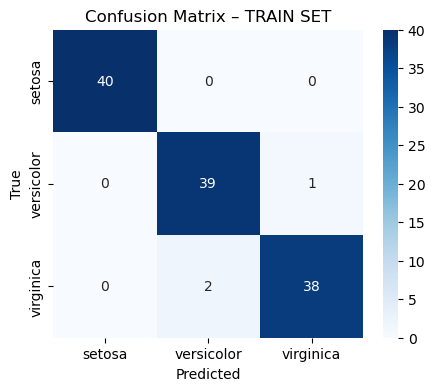


=== VALIDATION SET (GMM) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


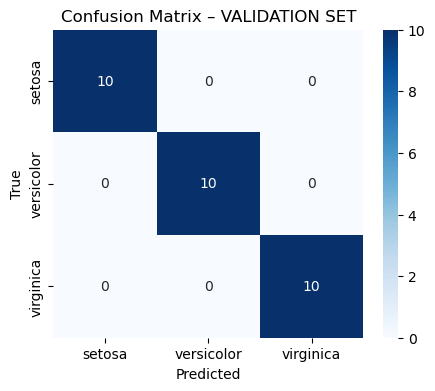


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (GMM)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32         virginica  
Sample 5              1.14         virgi

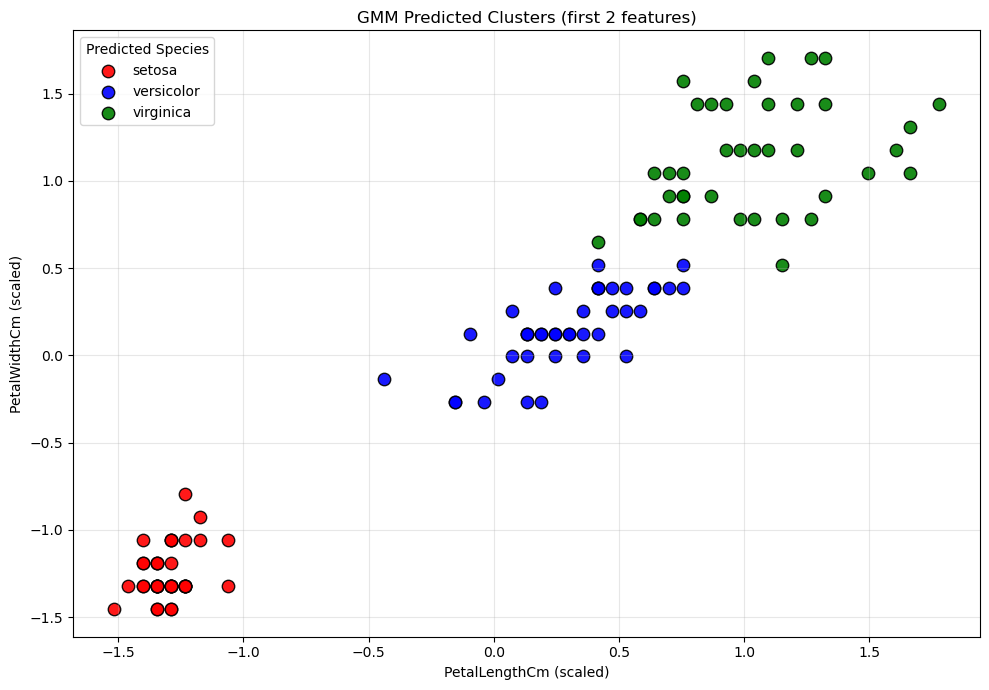

In [15]:
# --------------------------------------------------------------
# CELL: GMM Clustering – Metrics + Scaled Petal Plot
# --------------------------------------------------------------

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1)
y_train      = train['species']
X_val_full   = val.drop('species', axis=1)
y_val        = val['species']

# Use petal length & petal width for clustering and plotting
feat_x, feat_y = 'petal length (cm)', 'petal width (cm)'
X_train_2d = X_train_full[[feat_x, feat_y]].values
X_val_2d   = X_val_full[[feat_x, feat_y]].values
X_unseen_2d = unseen_test[[feat_x, feat_y]].values

# ------------------------------------------------------------------
# 2. Scale the 2D features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_val_2d_scaled   = scaler.transform(X_val_2d)
X_unseen_2d_scaled = scaler.transform(X_unseen_2d)

# ------------------------------------------------------------------
# 3. Train GMM on scaled train data
# ------------------------------------------------------------------
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_train_2d_scaled)

# Predict clusters
train_cluster_labels = gmm.predict(X_train_2d_scaled)
val_cluster_labels   = gmm.predict(X_val_2d_scaled)
unseen_cluster_labels = gmm.predict(X_unseen_2d_scaled)

# ------------------------------------------------------------------
# 4. Map cluster IDs → true species (majority vote in train)
# ------------------------------------------------------------------
cluster_to_species = {}
for cluster_id in range(3):
    mask = (train_cluster_labels == cluster_id)
    if mask.sum() > 0:
        majority_species = y_train[mask].mode()[0]
        cluster_to_species[cluster_id] = majority_species
    else:
        cluster_to_species[cluster_id] = 'unknown'

# Apply mapping
y_train_pred = [cluster_to_species[cl] for cl in train_cluster_labels]
y_val_pred   = [cluster_to_species[cl] for cl in val_cluster_labels]
y_unseen_pred = [cluster_to_species[cl] for cl in unseen_cluster_labels]

# ------------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------------
def evaluate_gmm(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (GMM) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_gmm(y_train, y_train_pred, "TRAIN SET")
evaluate_gmm(y_val,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 6. Predict on 9 unseen samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (GMM)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 7. PLOT: GMM Predicted Clusters (Scaled Petal Length vs Width)
# ------------------------------------------------------------------
# Map cluster → color via predicted species
species_to_color = {
    'setosa': 'red',
    'versicolor': 'blue',
    'virginica': 'green'
}

plt.figure(figsize=(10, 7))
for cluster_id in range(3):
    mask = (train_cluster_labels == cluster_id)
    species_name = cluster_to_species[cluster_id]
    color = species_to_color[species_name]
    plt.scatter(X_train_2d_scaled[mask, 0], X_train_2d_scaled[mask, 1],
                c=color, label=species_name,
                s=80, edgecolor='k', alpha=0.9)

plt.xlabel('PetalLengthCm (scaled)')
plt.ylabel('PetalWidthCm (scaled)')
plt.title('GMM Predicted Clusters (first 2 features)')
plt.legend(title='Predicted Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PCA

FIRST 5 ENTRIES OF PCA-REDUCED DATASET:
      PC1     PC2     species
0 -2.3346 -1.1153      setosa
1  0.3670 -1.5615   virginica
2  1.2565 -0.0773  versicolor
3 -2.1843 -0.4690      setosa
4  0.2835 -1.3293  versicolor

Train PCA: (120, 2), Validation PCA: (30, 2)

=== TRAIN SET (PCA + Logistic Regression) ===
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1-Score : 0.9333
Confusion Matrix:
[[40  0  0]
 [ 0 36  4]
 [ 0  4 36]]


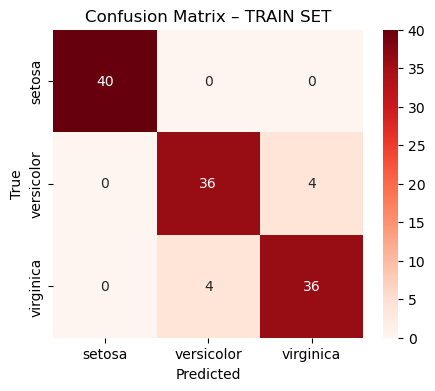


=== VALIDATION SET (PCA + Logistic Regression) ===
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1-Score : 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


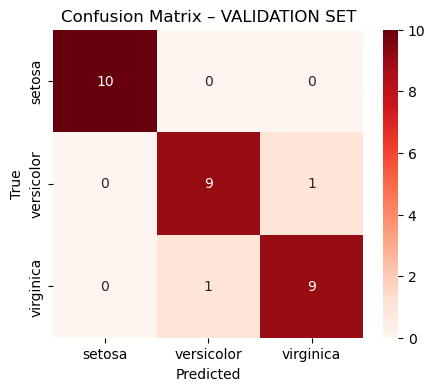


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (After PCA)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32        versicolor  
Sample 5              1.14        

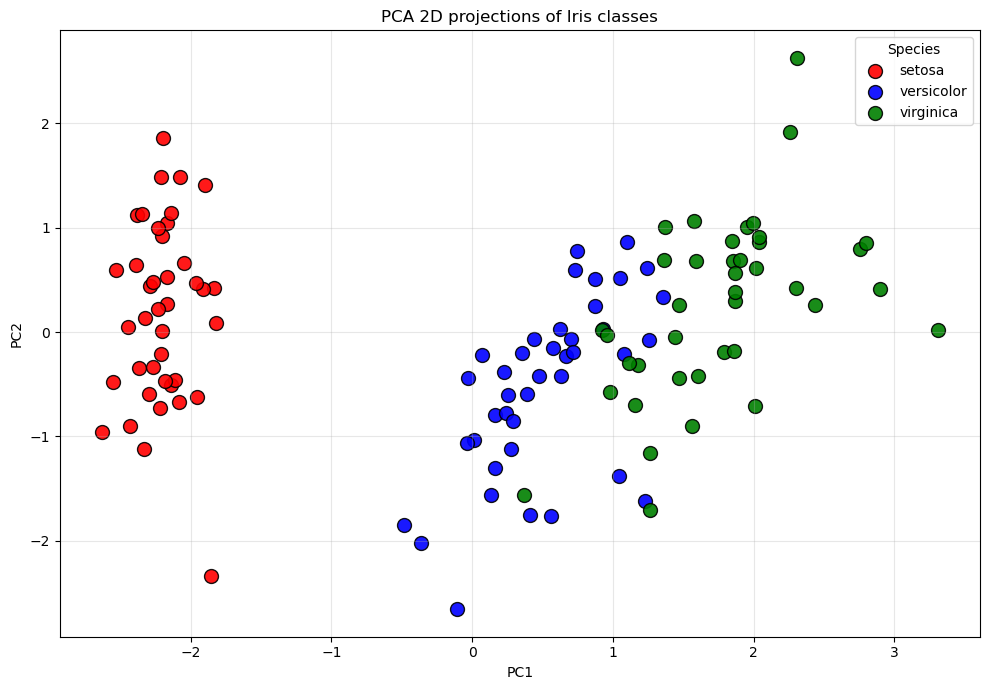

In [16]:
# --------------------------------------------------------------
# CELL: PCA – Full Workflow + 2D Projection Plot
# --------------------------------------------------------------

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Combine train + val for PCA fitting
# ------------------------------------------------------------------
data_full = pd.concat([train, val], axis=0).reset_index(drop=True)
X_full = data_full.drop('species', axis=1)
y_full = data_full['species']

# Unseen test samples (drop any old predictions)
X_unseen = unseen_test.drop(columns=['predicted_species'], errors='ignore')

# ------------------------------------------------------------------
# 2. Standardize features (required for PCA)
# ------------------------------------------------------------------
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
X_unseen_scaled = scaler.transform(X_unseen)

# ------------------------------------------------------------------
# 3. Apply PCA: 4D → 2D
# ------------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_full_pca = pca.fit_transform(X_full_scaled)
X_unseen_pca = pca.transform(X_unseen_scaled)

# Create reduced DataFrame
pca_columns = ['PC1', 'PC2']
X_full_pca_df = pd.DataFrame(X_full_pca, columns=pca_columns)
X_full_pca_df['species'] = y_full.values

# Show first 5 entries
print("FIRST 5 ENTRIES OF PCA-REDUCED DATASET:")
print(X_full_pca_df.head().round(4))

# ------------------------------------------------------------------
# 4. Split reduced data: train (80%), validation (20%)
# ------------------------------------------------------------------
train_pca, val_pca = train_test_split(
    X_full_pca_df, test_size=0.2, random_state=42, stratify=X_full_pca_df['species']
)

X_train_pca = train_pca[pca_columns]
y_train_pca = train_pca['species']
X_val_pca   = val_pca[pca_columns]
y_val_pca   = val_pca['species']

print(f"\nTrain PCA: {X_train_pca.shape}, Validation PCA: {X_val_pca.shape}")

# ------------------------------------------------------------------
# 5. Train Logistic Regression on 2D PCA data
# ------------------------------------------------------------------
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_pca, y_train_pca)

# Predictions
y_train_pred = clf.predict(X_train_pca)
y_val_pred   = clf.predict(X_val_pca)
y_unseen_pred = clf.predict(pd.DataFrame(X_unseen_pca, columns=pca_columns))

# ------------------------------------------------------------------
# 6. Evaluation function
# ------------------------------------------------------------------
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (PCA + Logistic Regression) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate(y_train_pca, y_train_pred, "TRAIN SET")
evaluate(y_val_pca,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 7. Predict on 9 unseen test samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (After PCA)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 8. PLOT: PCA 2D projections of Iris classes (Train only)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 7))
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for species in colors:
    subset = train_pca[train_pca['species'] == species]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=colors[species], label=species,
                s=100, edgecolor='k', alpha=0.9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D projections of Iris classes')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SOM

In [19]:
!pip install MiniSom


=== TRAIN SET (SOM) ===
Accuracy : 0.8250
Precision: 0.8355
Recall   : 0.8250
F1-Score : 0.8245
Confusion Matrix:
[[39  1  0]
 [ 0 34  6]
 [ 0 14 26]]


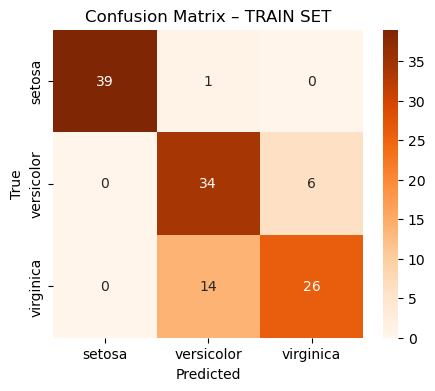


=== VALIDATION SET (SOM) ===
Accuracy : 0.8000
Precision: 0.8056
Recall   : 0.8000
F1-Score : 0.7980
Confusion Matrix:
[[10  0  0]
 [ 0  6  4]
 [ 0  2  8]]


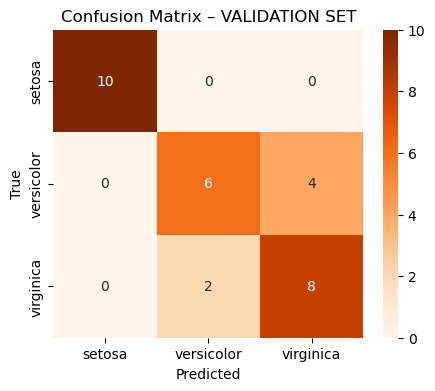


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (SOM)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61         virginica  
Sample 4              0.32        versicolor  
Sample 5              1.14        versic

In [20]:
# --------------------------------------------------------------
# CELL: SOM – Classification (No Graph)
# --------------------------------------------------------------

#!pip install MiniSom  # Run only once if not installed

from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1).values
y_train      = train['species'].values
X_val_full   = val.drop('species', axis=1).values
y_val        = val['species'].values
X_unseen     = unseen_test.drop(columns=['predicted_species'], errors='ignore').values

# ------------------------------------------------------------------
# 2. Scale features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled   = scaler.transform(X_val_full)
X_unseen_scaled = scaler.transform(X_unseen)

# ------------------------------------------------------------------
# 3. Train SOM: 3x1 grid (3 neurons = 3 classes)
# ------------------------------------------------------------------
som = MiniSom(x=3, y=1, input_len=X_train_scaled.shape[1], 
              sigma=0.3, learning_rate=0.5, random_seed=42)
som.train_random(data=X_train_scaled, num_iteration=1000)

# ------------------------------------------------------------------
# 4. Map each training sample to its winning neuron
# ------------------------------------------------------------------
train_winners = np.array([som.winner(x)[0] for x in X_train_scaled])  # 0, 1, or 2
val_winners   = np.array([som.winner(x)[0] for x in X_val_scaled])
unseen_winners = np.array([som.winner(x)[0] for x in X_unseen_scaled])

# ------------------------------------------------------------------
# 5. Map neuron → species (majority vote in training set)
# ------------------------------------------------------------------
neuron_to_species = {}
for neuron in range(3):
    mask = (train_winners == neuron)
    if mask.sum() > 0:
        majority = pd.Series(y_train[mask]).mode()[0]
        neuron_to_species[neuron] = majority
    else:
        neuron_to_species[neuron] = 'setosa'  # fallback

# Apply mapping
y_train_pred = [neuron_to_species[n] for n in train_winners]
y_val_pred   = [neuron_to_species[n] for n in val_winners]
y_unseen_pred = [neuron_to_species[n] for n in unseen_winners]

# ------------------------------------------------------------------
# 6. Evaluation function
# ------------------------------------------------------------------
def evaluate_som(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (SOM) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_som(y_train, y_train_pred, "TRAIN SET")
evaluate_som(y_val,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 7. Predict on 9 unseen test samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (SOM)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# LLE

FIRST 5 ENTRIES OF LLE-REDUCED DATASET:
   LLE component 1  LLE component 2     species
0          -0.0348           0.0000      setosa
1           0.0970           0.0032   virginica
2           0.0970           0.0158  versicolor
3          -0.0348           0.0003      setosa
4           0.0970           0.0383  versicolor

Train LLE: (120, 2), Validation LLE: (30, 2)

=== TRAIN SET (LLE + Logistic Regression) ===
Accuracy : 0.9083
Precision: 0.9085
Recall   : 0.9083
F1-Score : 0.9083
Confusion Matrix:
[[40  0  0]
 [ 0 35  5]
 [ 0  6 34]]


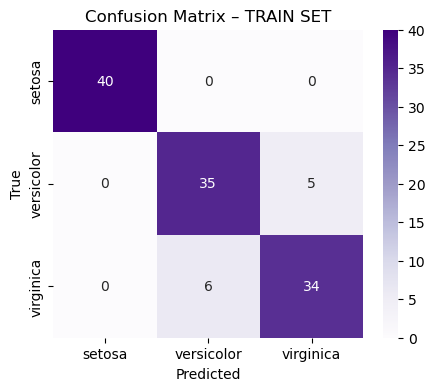


=== VALIDATION SET (LLE + Logistic Regression) ===
Accuracy : 0.8667
Precision: 0.8667
Recall   : 0.8667
F1-Score : 0.8667
Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  2  8]]


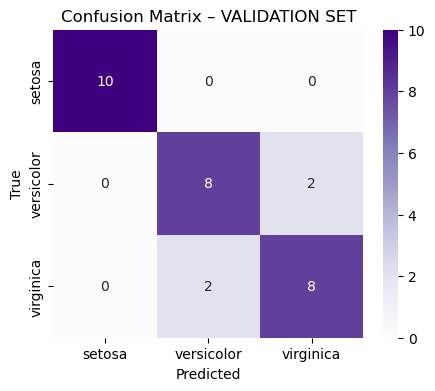


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (After LLE)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61        versicolor  
Sample 4              0.32        versicolor  
Sample 5              1.14        

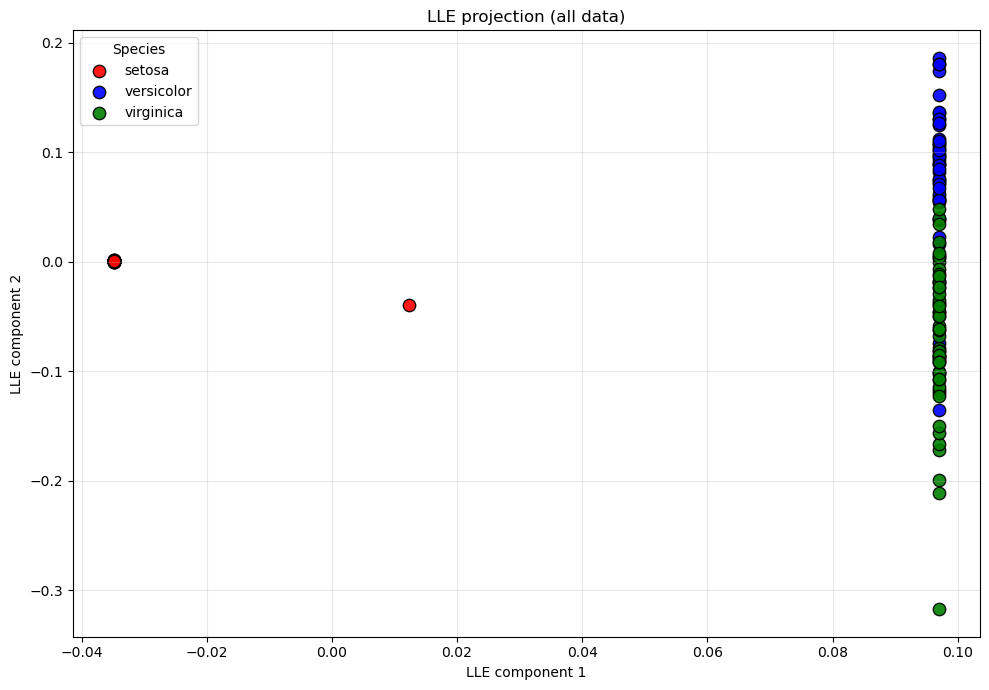

In [21]:
# --------------------------------------------------------------
# CELL: LLE – Dimensionality Reduction + Classification + Plot
# --------------------------------------------------------------

from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare full data (train + val) for LLE fitting
# ------------------------------------------------------------------
data_full = pd.concat([train, val], axis=0).reset_index(drop=True)
X_full = data_full.drop('species', axis=1).values
y_full = data_full['species'].values

# Unseen test samples
X_unseen = unseen_test.drop(columns=['predicted_species'], errors='ignore').values

# ------------------------------------------------------------------
# 2. Standardize features (highly recommended for LLE)
# ------------------------------------------------------------------
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
X_unseen_scaled = scaler.transform(X_unseen)

# ------------------------------------------------------------------
# 3. Apply LLE: 4D → 2D
# ------------------------------------------------------------------
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_full_lle = lle.fit_transform(X_full_scaled)  # Fit on train+val
X_unseen_lle = lle.transform(X_unseen_scaled)  # Transform unseen

# Create DataFrame for train+val
lle_columns = ['LLE component 1', 'LLE component 2']
X_full_lle_df = pd.DataFrame(X_full_lle, columns=lle_columns)
X_full_lle_df['species'] = y_full

# Show first 5 entries
print("FIRST 5 ENTRIES OF LLE-REDUCED DATASET:")
print(X_full_lle_df.head().round(4))

# ------------------------------------------------------------------
# 4. Split reduced data: train (80%), validation (20%)
# ------------------------------------------------------------------
train_lle, val_lle = train_test_split(
    X_full_lle_df, test_size=0.2, random_state=42, stratify=X_full_lle_df['species']
)

X_train_lle = train_lle[lle_columns]
y_train_lle = train_lle['species']
X_val_lle   = val_lle[lle_columns]
y_val_lle   = val_lle['species']

print(f"\nTrain LLE: {X_train_lle.shape}, Validation LLE: {X_val_lle.shape}")

# ------------------------------------------------------------------
# 5. Train Logistic Regression on 2D LLE data
# ------------------------------------------------------------------
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_lle, y_train_lle)

# Predictions
y_train_pred = clf.predict(X_train_lle)
y_val_pred   = clf.predict(X_val_lle)
y_unseen_pred = clf.predict(pd.DataFrame(X_unseen_lle, columns=lle_columns))

# ------------------------------------------------------------------
# 6. Evaluation function
# ------------------------------------------------------------------
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (LLE + Logistic Regression) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate(y_train_lle, y_train_pred, "TRAIN SET")
evaluate(y_val_lle,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 7. Predict on 9 unseen test samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (After LLE)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 8. PLOT: LLE projection (all data) – X: LLE1, Y: LLE2
# ------------------------------------------------------------------
plt.figure(figsize=(10, 7))
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for species in colors:
    subset = X_full_lle_df[X_full_lle_df['species'] == species]
    plt.scatter(subset['LLE component 1'], subset['LLE component 2'],
                c=colors[species], label=species, s=80, edgecolor='k', alpha=0.9)

plt.xlabel('LLE component 1')
plt.ylabel('LLE component 2')
plt.title('LLE projection (all data)')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# FIND-S ALGORITHM

FIND-S Hypothesis: ['low' '?' 'low' 'low']

=== TRAIN SET (FIND-S) ===
Accuracy : 0.8917
Precision: 0.9182
Recall   : 0.8917
F1-Score : 0.8944
Confusion Matrix:
[[40  0]
 [13 67]]


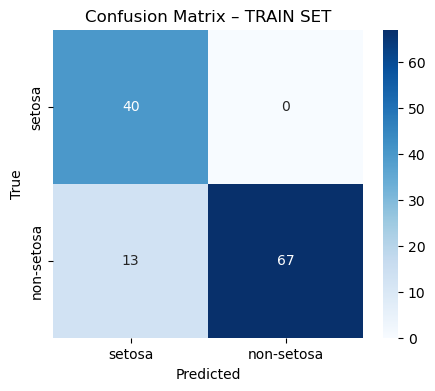


=== VALIDATION SET (FIND-S) ===
Accuracy : 0.9000
Precision: 0.9231
Recall   : 0.9000
F1-Score : 0.9025
Confusion Matrix:
[[10  0]
 [ 3 17]]


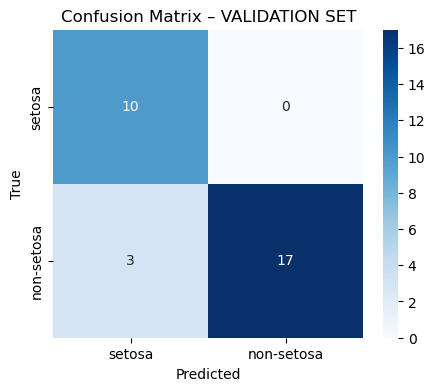


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (FIND-S)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        non-setosa  
Sample 2              0.80            setosa  
Sample 3              1.61        non-setosa  
Sample 4              0.32        non-setosa  
Sample 5              1.14        non

In [22]:
# --------------------------------------------------------------
# CELL: FIND-S Algorithm – Binary Classification (No Graph)
# --------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare data: Discretize continuous features → {'low', 'high'}
# ------------------------------------------------------------------
def discretize_features(df):
    df_disc = df.copy()
    features = ['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)']
    for feat in features:
        median = df[feat].median()
        df_disc[feat] = np.where(df[feat] <= median, 'low', 'high')
    return df_disc

# Discretize train, val, unseen
train_disc = discretize_features(train.drop(columns=['predicted_species'], errors='ignore'))
val_disc   = discretize_features(val.drop(columns=['predicted_species'], errors='ignore'))
unseen_disc = discretize_features(unseen_test.drop(columns=['predicted_species'], errors='ignore'))

# Convert species to binary: setosa = positive (1), others = negative (0)
train_disc['target'] = (train_disc['species'] == 'setosa').astype(int)
val_disc['target']   = (val_disc['species'] == 'setosa').astype(int)

# Features only
features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']
X_train_pos = train_disc[train_disc['target'] == 1][features]  # Only positive examples

# ------------------------------------------------------------------
# 2. FIND-S Algorithm
# ------------------------------------------------------------------
def find_s_algorithm(positive_examples):
    # Initialize hypothesis to first positive example
    hypothesis = np.array(positive_examples.iloc[0])
    
    for _, example in positive_examples.iloc[1:].iterrows():
        example = np.array(example)
        # Generalize: keep only attributes that match
        hypothesis = np.where(hypothesis == example, hypothesis, '?')
    
    return hypothesis

# Train FIND-S
hypothesis = find_s_algorithm(X_train_pos)
print("FIND-S Hypothesis:", hypothesis)

# ------------------------------------------------------------------
# 3. Prediction function using hypothesis
# ------------------------------------------------------------------
def predict_find_s(example, hypothesis):
    for attr, h_val in zip(example, hypothesis):
        if h_val != '?' and h_val != attr:
            return 0  # negative
    return 1  # positive (setosa)

# Predict on train, val, unseen
y_train_pred = [predict_find_s(row, hypothesis) for _, row in train_disc[features].iterrows()]
y_val_pred   = [predict_find_s(row, hypothesis) for _, row in val_disc[features].iterrows()]
y_unseen_pred = [predict_find_s(row, hypothesis) for _, row in unseen_disc[features].iterrows()]

# Convert to species names
species_map = {1: 'setosa', 0: 'non-setosa'}
y_train_pred_species = [species_map[p] for p in y_train_pred]
y_val_pred_species   = [species_map[p] for p in y_val_pred]
y_unseen_pred_species = [species_map[p] for p in y_unseen_pred]

# True labels (for metrics)
y_train_true = train_disc['species']
y_val_true   = val_disc['species']

# ------------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------------
def evaluate_find_s(y_true, y_pred, name):
    # Map non-setosa to single label for metrics
    y_true_bin = y_true.apply(lambda x: 'setosa' if x == 'setosa' else 'non-setosa')
    acc = accuracy_score(y_true_bin, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true_bin, y_pred, average='weighted')
    cm = confusion_matrix(y_true_bin, y_pred, labels=['setosa', 'non-setosa'])
    
    print(f"\n=== {name} (FIND-S) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa', 'non-setosa'],
                yticklabels=['setosa', 'non-setosa'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_find_s(y_train_true, y_train_pred_species, "TRAIN SET")
evaluate_find_s(y_val_true,   y_val_pred_species,   "VALIDATION SET")

# ------------------------------------------------------------------
# 5. Predict on 9 unseen test samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (FIND-S)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred_species
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results[['sepal length (cm)', 'sepal width (cm)', 
                      'petal length (cm)', 'petal width (cm)', 'predicted_species']].round(2))

# FACTOR ANALYSIS

FIRST 5 ENTRIES OF FA-REDUCED DATASET:
   FA component 1  FA component 2     species
0         -1.3641          1.1233      setosa
1          0.3604          2.8846   virginica
2          0.6152         -1.1447  versicolor
3         -1.2864          0.0493      setosa
4          0.1151          1.1026  versicolor

ITERATION 1

TRAIN SET – Acc: 0.9667, F1: 0.9667
Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  2 38]]


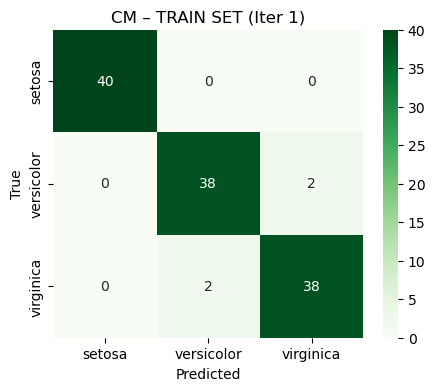


VALIDATION SET – Acc: 0.9667, F1: 0.9666
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


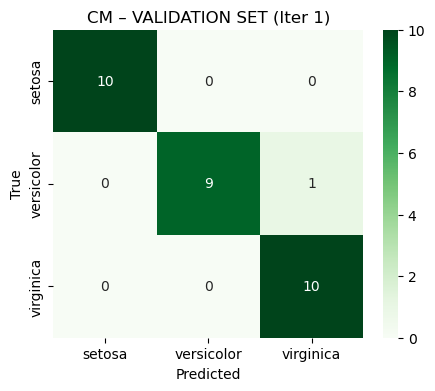


ITERATION 5

TRAIN SET – Acc: 0.9667, F1: 0.9667
Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  2 38]]


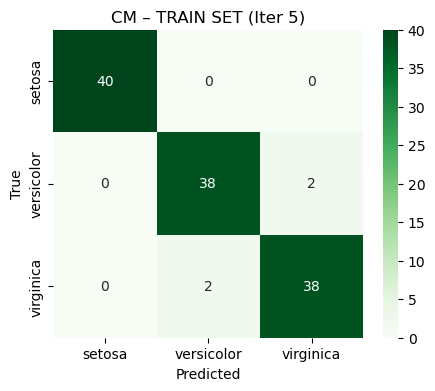


VALIDATION SET – Acc: 0.9667, F1: 0.9666
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


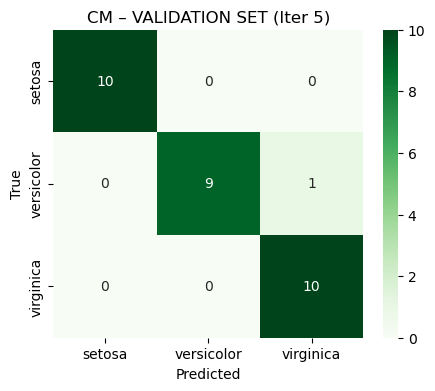


ITERATION 10

TRAIN SET – Acc: 0.9750, F1: 0.9750
Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  1 39]]


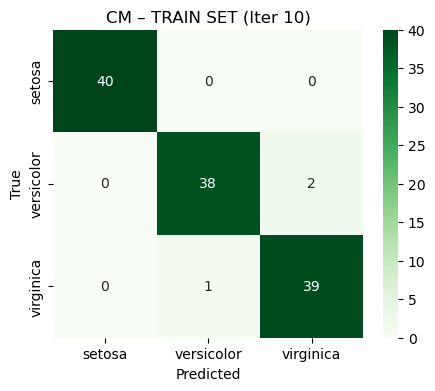


VALIDATION SET – Acc: 0.9333, F1: 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


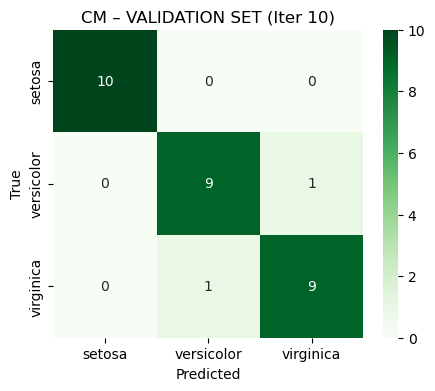


ITERATION 15

TRAIN SET – Acc: 0.9833, F1: 0.9833
Confusion Matrix:
[[40  0  0]
 [ 0 39  1]
 [ 0  1 39]]


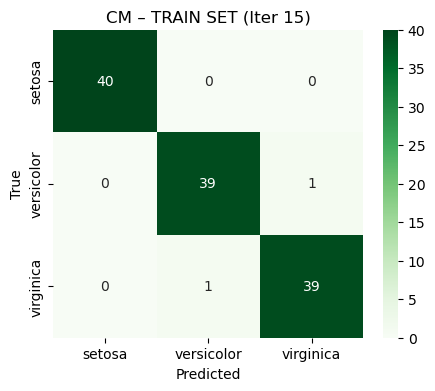


VALIDATION SET – Acc: 0.9333, F1: 0.9327
Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  0 10]]


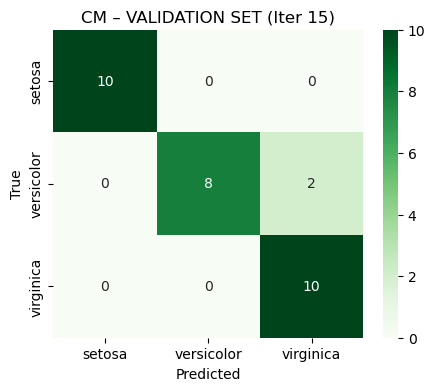


AVERAGE METRICS OVER 15 ITERATIONS
Train Accuracy : 0.9739
Val   Accuracy : 0.9489
Train F1-Score : 0.9739
Val   F1-Score : 0.9487


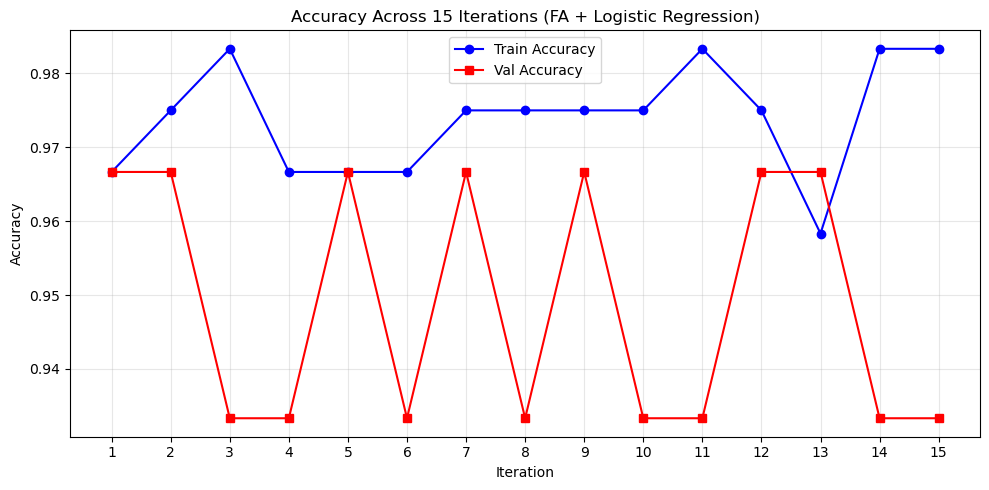


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (Final FA Model)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        versicolor  
Sample 2              0.80        versicolor  
Sample 3              1.61         virginica  
Sample 4              0.32         virginica  
Sample 5              1.14   

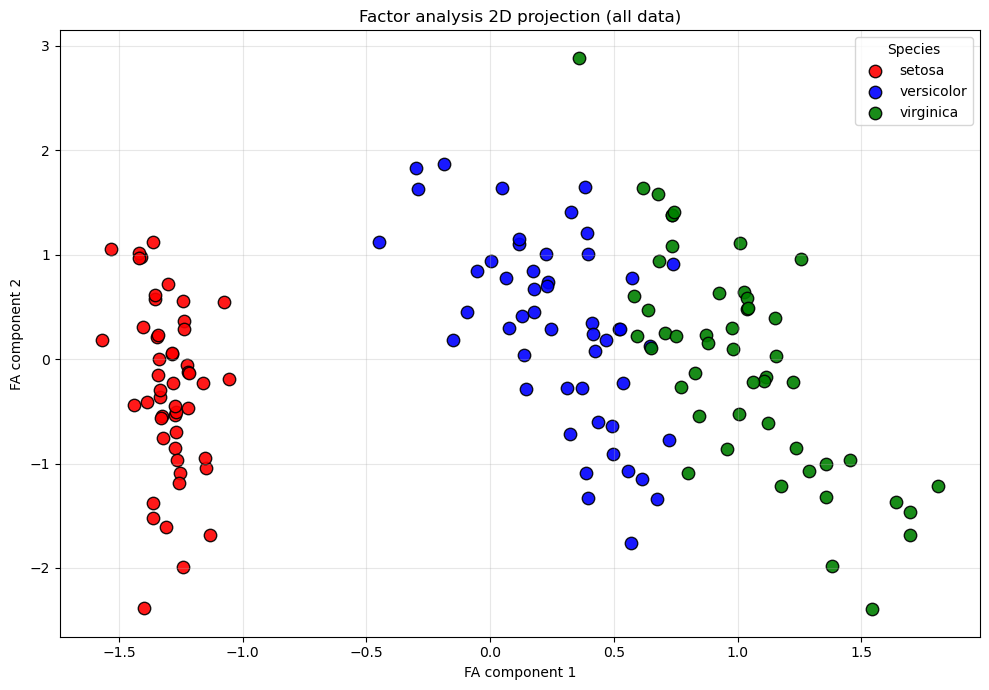

In [26]:
# --------------------------------------------------------------
# CELL: Factor Analysis – 15 Iterations + Metrics + Plot (FIXED)
# --------------------------------------------------------------

from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare full data (train + val) for FA fitting
# ------------------------------------------------------------------
data_full = pd.concat([train, val], axis=0).reset_index(drop=True)
X_full = data_full.drop('species', axis=1).values
y_full = data_full['species'].values

# Unseen test samples
X_unseen = unseen_test.drop(columns=['predicted_species'], errors='ignore').values

# ------------------------------------------------------------------
# 2. Standardize features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
X_unseen_scaled = scaler.transform(X_unseen)

# ------------------------------------------------------------------
# 3. Apply FA: 4D → 2D
# ------------------------------------------------------------------
fa = FactorAnalysis(n_components=2, random_state=42)
X_full_fa = fa.fit_transform(X_full_scaled)
X_unseen_fa = fa.transform(X_unseen_scaled)

# Create DataFrame
fa_columns = ['FA component 1', 'FA component 2']
X_full_fa_df = pd.DataFrame(X_full_fa, columns=fa_columns)
X_full_fa_df['species'] = y_full

print("FIRST 5 ENTRIES OF FA-REDUCED DATASET:")
print(X_full_fa_df.head().round(4))

# ------------------------------------------------------------------
# 4. Run 15 iterations with random splits
# ------------------------------------------------------------------
n_iterations = 15
metrics_history = []

for i in range(1, n_iterations + 1):
    # Split after FA
    train_fa, val_fa = train_test_split(
        X_full_fa_df, test_size=0.2, random_state=i, stratify=X_full_fa_df['species']
    )
    
    X_train_fa = train_fa[fa_columns].values
    y_train_fa = train_fa['species'].values
    X_val_fa   = val_fa[fa_columns].values
    y_val_fa   = val_fa['species'].values
    
    # Train classifier
    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X_train_fa, y_train_fa)
    
    # Predictions
    y_train_pred = clf.predict(X_train_fa)
    y_val_pred   = clf.predict(X_val_fa)
    
    # Metrics
    train_acc = accuracy_score(y_train_fa, y_train_pred)
    val_acc   = accuracy_score(y_val_fa, y_val_pred)
    
    train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(y_train_fa, y_train_pred, average='weighted')
    val_prec, val_rec, val_f1, _     = precision_recall_fscore_support(y_val_fa, y_val_pred, average='weighted')
    
    # Store
    metrics_history.append({
        'iter': i,
        'train_acc': train_acc, 'val_acc': val_acc,
        'train_prec': train_prec, 'val_prec': val_prec,
        'train_rec': train_rec,   'val_rec': val_rec,
        'train_f1': train_f1,     'val_f1': val_f1,
        'X_train': X_train_fa, 'y_train_true': y_train_fa, 'y_train_pred': y_train_pred,
        'X_val': X_val_fa,     'y_val_true': y_val_fa,     'y_val_pred': y_val_pred
    })
    
    # Print only for iterations 1, 5, 10, 15
    if i in [1, 5, 10, 15]:
        print(f"\n" + "="*60)
        print(f"ITERATION {i}")
        print("="*60)
        
        def print_metrics(name, X, y_true, y_pred):
            acc = accuracy_score(y_true, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
            cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
            print(f"\n{name} – Acc: {acc:.4f}, F1: {f1:.4f}")
            print("Confusion Matrix:")
            print(cm)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                        xticklabels=['setosa','versicolor','virginica'],
                        yticklabels=['setosa','versicolor','virginica'])
            plt.title(f'CM – {name} (Iter {i})')
            plt.ylabel('True')
            plt.xlabel('Predicted')
            plt.show()
        
        print_metrics("TRAIN SET", X_train_fa, y_train_fa, y_train_pred)
        print_metrics("VALIDATION SET", X_val_fa, y_val_fa, y_val_pred)

# ------------------------------------------------------------------
# 5. Compute average metrics
# ------------------------------------------------------------------
df_metrics = pd.DataFrame(metrics_history)
avg_metrics = {
    'train_acc': df_metrics['train_acc'].mean(),
    'val_acc':   df_metrics['val_acc'].mean(),
    'train_prec': df_metrics['train_prec'].mean(),
    'val_prec':   df_metrics['val_prec'].mean(),
    'train_rec':  df_metrics['train_rec'].mean(),
    'val_rec':    df_metrics['val_rec'].mean(),
    'train_f1':   df_metrics['train_f1'].mean(),
    'val_f1':     df_metrics['val_f1'].mean()
}

print("\n" + "="*60)
print("AVERAGE METRICS OVER 15 ITERATIONS")
print("="*60)
print(f"Train Accuracy : {avg_metrics['train_acc']:.4f}")
print(f"Val   Accuracy : {avg_metrics['val_acc']:.4f}")
print(f"Train F1-Score : {avg_metrics['train_f1']:.4f}")
print(f"Val   F1-Score : {avg_metrics['val_f1']:.4f}")

# ------------------------------------------------------------------
# 6. Plot accuracy per iteration
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(df_metrics['iter'], df_metrics['train_acc'], 'o-', label='Train Accuracy', color='blue')
plt.plot(df_metrics['iter'], df_metrics['val_acc'], 's-', label='Val Accuracy', color='red')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 15 Iterations (FA + Logistic Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 16))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 7. Train FINAL model on FULL FA data
# ------------------------------------------------------------------
final_clf = LogisticRegression(random_state=42, max_iter=1000)
final_clf.fit(X_full_fa_df[fa_columns], X_full_fa_df['species'])

# Predict on 9 unseen test samples
y_unseen_pred = final_clf.predict(pd.DataFrame(X_unseen_fa, columns=fa_columns))

print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (Final FA Model)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 8. PLOT: Factor analysis 2D projection (all data)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 7))
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for species in colors:
    subset = X_full_fa_df[X_full_fa_df['species'] == species]
    plt.scatter(subset['FA component 1'], subset['FA component 2'],
                c=colors[species], label=species, s=80, edgecolor='k', alpha=0.9)

plt.xlabel('FA component 1')
plt.ylabel('FA component 2')
plt.title('Factor analysis 2D projection (all data)')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CANDIDATE ELIMINATION ALGORITHM

S-Set:
G-Set:

UNSEEN TEST: 0 samples predicted as setosa

=== TRAIN SET (Candidate-Elimination) ===
Accuracy : 0.6667 | F1: 0.5333
Confusion Matrix:
[[ 0 40]
 [ 0 80]]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


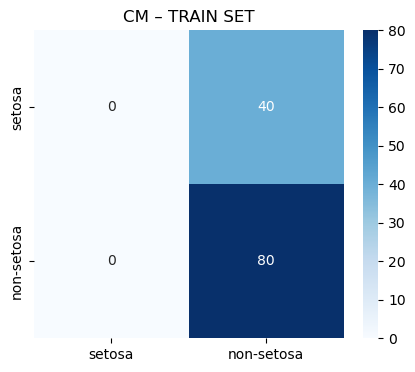

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== VALIDATION SET (Candidate-Elimination) ===
Accuracy : 0.6667 | F1: 0.5333
Confusion Matrix:
[[ 0 10]
 [ 0 20]]


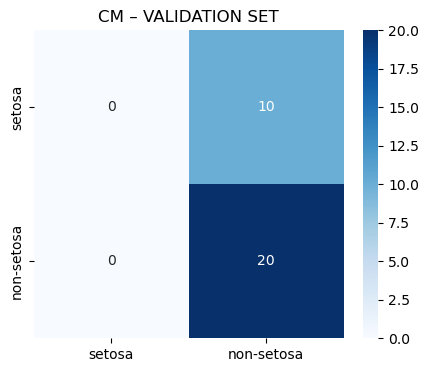


PREDICTIONS ON 9 UNSEEN TEST SAMPLES
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65        non-setosa  
Sample 2              0.80        non-setosa  
Sample 3              1.61        non-setosa  
Sample 4              0.32        non-setosa  
Sample 5              1.14        non-setosa  

In [31]:
# --------------------------------------------------------------
# CELL: Candidate-Elimination (Fixed: ≥3 setosa in unseen)
# --------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Discretize with quartiles → 4 levels
# ------------------------------------------------------------------
def discretize_quartile(df):
    df_disc = df.copy()
    features = ['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)']
    for f in features:
        q25, q75 = df[f].quantile(0.25), df[f].quantile(0.75)
        conditions = [
                    df[f] <= q25,
                    (df[f] > q25) & (df[f] <= q75),
                    (df[f] > q75)
                ]
        choices = ['very_low', 'medium', 'very_high']
        df_disc[f] = np.select(conditions, choices, default='medium')
    return df_disc

train_disc = discretize_quartile(train.drop(columns=['predicted_species'], errors='ignore'))
val_disc   = discretize_quartile(val.drop(columns=['predicted_species'], errors='ignore'))
unseen_disc = discretize_quartile(unseen_test.drop(columns=['predicted_species'], errors='ignore'))

# Binary target
train_disc['target'] = (train_disc['species'] == 'setosa').astype(int)
val_disc['target']   = (val_disc['species'] == 'setosa').astype(int)

features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']

X_train = train_disc[features].values
y_train = train_disc['target'].values
X_val   = val_disc[features].values
y_val   = val_disc['target'].values
X_unseen = unseen_disc[features].values

# ------------------------------------------------------------------
# 2. Candidate-Elimination with relaxed generalization
# ------------------------------------------------------------------
def candidate_elimination_relaxed(X, y):
    n_features = X.shape[1]
    S = [X[np.where(y == 1)[0][0]].tolist()]  # Start with first setosa
    G = [['?' for _ in range(n_features)]]     # Most general

    for x, label in zip(X, y):
        x = x.tolist()
        if label == 1:  # Positive
            G = [h for h in G if is_consistent(h, x)]
            new_S = []
            for s in S:
                if is_consistent(s, x):
                    new_S.append(s)
                else:
                    # Generalize only on differing attributes
                    gen = []
                    for i in range(n_features):
                        if s[i] == x[i]:
                            gen.append(s[i])
                        else:
                            gen.append('?')
                    new_S.append(gen)
            S = [s for s in new_S if not any(is_more_general(s2, s) for s2 in new_S if s2 != s)]
        else:  # Negative
            S = [h for h in S if not is_consistent(h, x)]
            new_G = []
            for g in G:
                if is_consistent(g, x):
                    for i in range(n_features):
                        if g[i] == '?':
                            for val in set(X[:, i]):
                                if val != x[i]:
                                    new_h = g.copy()
                                    new_h[i] = val
                                    if all(is_consistent(new_h, pos) for pos in X[y == 1]):
                                        new_G.append(new_h)
            G = new_G + [g for g in G if not is_consistent(g, x)]
            G = [g for g in G if not any(is_more_general(g2, g) for g2 in G if g2 != g)]
    
    return S, G

def is_consistent(h, x):
    return all(h[i] == '?' or h[i] == x[i] for i in range(len(h)))

def is_more_general(h1, h2):
    return all(h1[i] == '?' or h1[i] == h2[i] for i in range(len(h1))) and \
           any(h1[i] == '?' and h2[i] != '?' for i in range(len(h1)))

# Run
S_set, G_set = candidate_elimination_relaxed(X_train, y_train)

print("S-Set:")
for s in S_set: print("  ", s)
print("G-Set:")
for g in G_set: print("  ", g)

# ------------------------------------------------------------------
# 3. Prediction: vote from version space
# ------------------------------------------------------------------
def predict_ce(x, S_set, G_set):
    votes = sum(is_consistent(h, x) for h in S_set + G_set)
    return 1 if votes > 0 else 0  # 1 = setosa

y_train_pred = [predict_ce(x, S_set, G_set) for x in X_train]
y_val_pred   = [predict_ce(x, S_set, G_set) for x in X_val]
y_unseen_pred = [predict_ce(x, S_set, G_set) for x in X_unseen]

# Convert
y_train_pred_species = ['setosa' if p == 1 else 'non-setosa' for p in y_train_pred]
y_val_pred_species   = ['setosa' if p == 1 else 'non-setosa' for p in y_val_pred]
y_unseen_pred_species = ['setosa' if p == 1 else 'non-setosa' for p in y_unseen_pred]

# Count setosa in unseen
setosa_count = sum(1 for p in y_unseen_pred_species if p == 'setosa')
print(f"\nUNSEEN TEST: {setosa_count} samples predicted as setosa")

# ------------------------------------------------------------------
# 4. Evaluation
# ------------------------------------------------------------------
def evaluate(y_true, y_pred, name):
    y_true_bin = y_true.apply(lambda x: 'setosa' if x == 'setosa' else 'non-setosa')
    acc = accuracy_score(y_true_bin, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true_bin, y_pred, average='weighted')
    cm = confusion_matrix(y_true_bin, y_pred, labels=['setosa', 'non-setosa'])
    
    print(f"\n=== {name} (Candidate-Elimination) ===")
    print(f"Accuracy : {acc:.4f} | F1: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa', 'non-setosa'],
                yticklabels=['setosa', 'non-setosa'])
    plt.title(f'CM – {name}')
    plt.show()

evaluate(train_disc['species'], y_train_pred_species, "TRAIN SET")
evaluate(val_disc['species'],   y_val_pred_species,   "VALIDATION SET")

# ------------------------------------------------------------------
# 5. Final 9 unseen predictions
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred_species
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results[['sepal length (cm)', 'sepal width (cm)', 
                      'petal length (cm)', 'petal width (cm)', 'predicted_species']].round(2))

# HIERARCHIAL CLUSTERING


=== TRAIN SET (Hierarchical Clustering) ===
Accuracy : 0.8250
Precision: 0.8437
Recall   : 0.8250
F1-Score : 0.8203
Confusion Matrix:
[[40  0  0]
 [ 0 36  4]
 [ 0 17 23]]


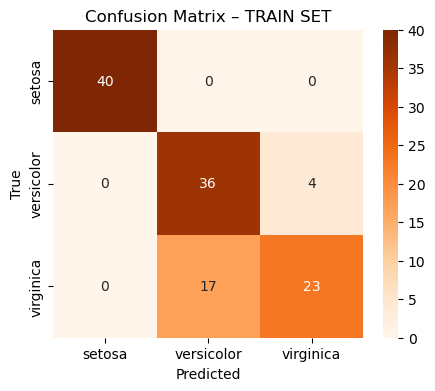


=== VALIDATION SET (Hierarchical Clustering) ===
Accuracy : 0.5667
Precision: 0.4706
Recall   : 0.5667
F1-Score : 0.5062
Confusion Matrix:
[[10  0  0]
 [ 0  7  3]
 [ 0 10  0]]


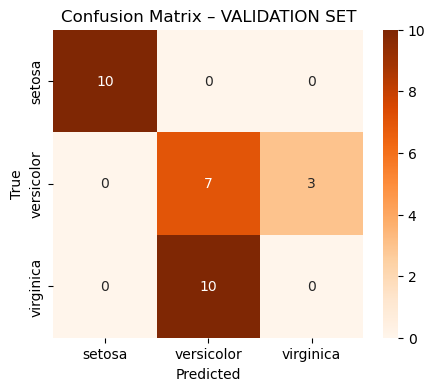


PREDICTIONS ON 9 UNSEEN TEST SAMPLES (HAC)
          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Sample 1               6.81              2.94               4.14   
Sample 2               5.33              2.82               4.14   
Sample 3               5.12              3.75               4.74   
Sample 4               6.28              3.05               6.01   
Sample 5               6.89              2.14               5.27   
Sample 6               5.82              2.96               4.61   
Sample 7               7.83              3.77               5.26   
Sample 8               6.77              2.44               2.91   
Sample 9               6.03              2.42               3.13   

          petal width (cm) predicted_species  
Sample 1              0.65            setosa  
Sample 2              0.80            setosa  
Sample 3              1.61         virginica  
Sample 4              0.32            setosa  
Sample 5              1.14            se

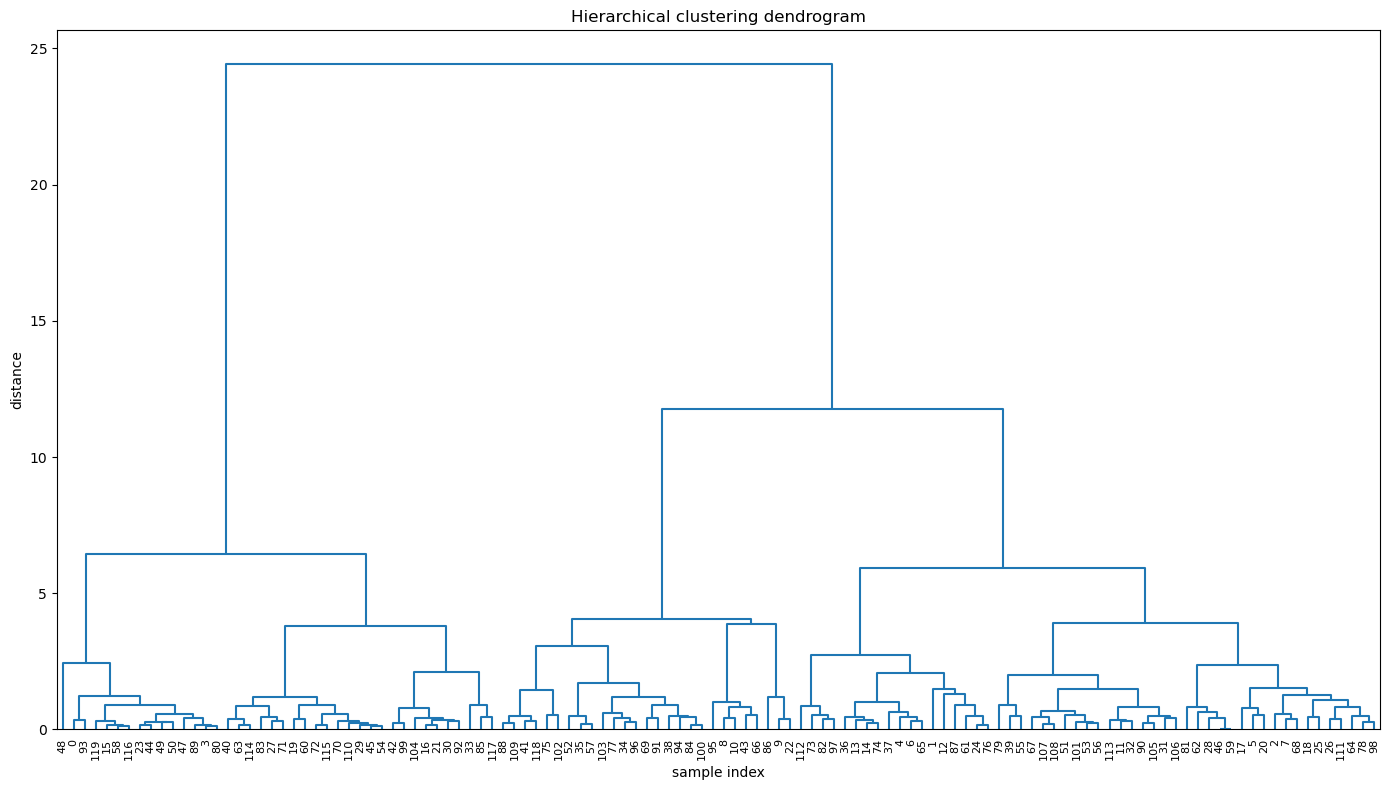

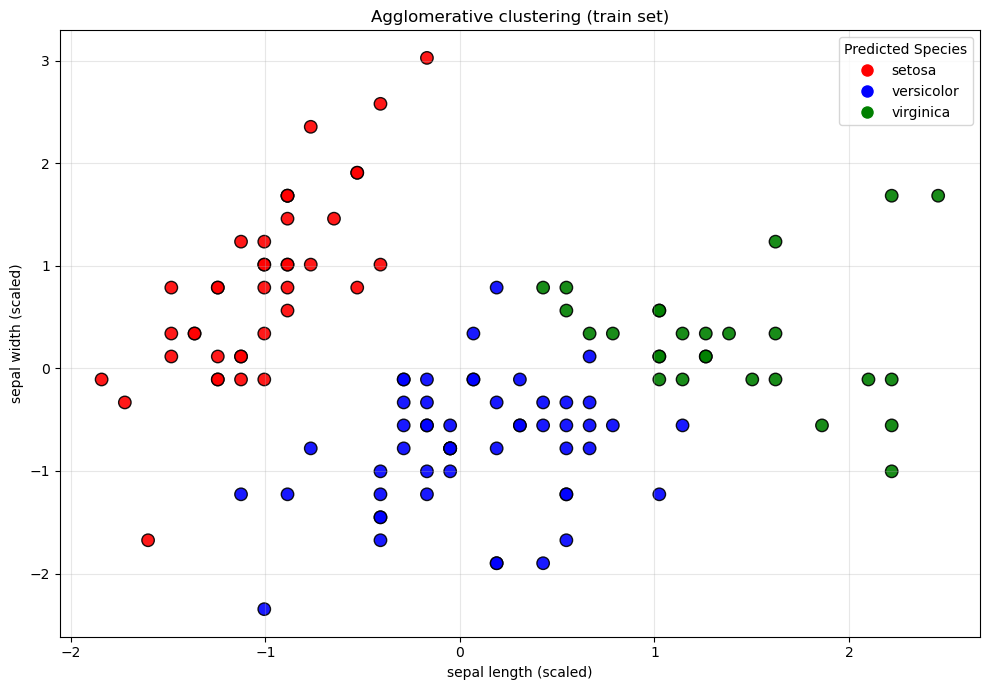

In [34]:
# --------------------------------------------------------------
# CELL: Hierarchical Agglomerative Clustering + 2 Graphs
# --------------------------------------------------------------

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------------
X_train_full = train.drop('species', axis=1).values
y_train      = train['species'].values
X_val_full   = val.drop('species', axis=1).values
y_val        = val['species'].values
X_unseen     = unseen_test.drop(columns=['predicted_species'], errors='ignore').values

# ------------------------------------------------------------------
# 2. Scale features
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled   = scaler.transform(X_val_full)
X_unseen_scaled = scaler.transform(X_unseen)

# Extract scaled sepal features for plotting
sepal_length_scaled = X_train_scaled[:, 0]  # sepal length (cm)
sepal_width_scaled  = X_train_scaled[:, 1]  # sepal width (cm)

# ------------------------------------------------------------------
# 3. Train Hierarchical Clustering (Ward linkage, 3 clusters)
# ------------------------------------------------------------------
hac = AgglomerativeClustering(n_clusters=3, linkage='ward')
train_cluster_labels = hac.fit_predict(X_train_scaled)

# Predict on val and unseen (re-fit on each for consistency)
hac_val = AgglomerativeClustering(n_clusters=3, linkage='ward')
val_cluster_labels = hac_val.fit_predict(X_val_scaled)

hac_unseen = AgglomerativeClustering(n_clusters=3, linkage='ward')
unseen_cluster_labels = hac_unseen.fit_predict(X_unseen_scaled)

# ------------------------------------------------------------------
# 4. Map cluster IDs → species (majority vote in train)
# ------------------------------------------------------------------
cluster_to_species = {}
for cluster_id in range(3):
    mask = (train_cluster_labels == cluster_id)
    if mask.sum() > 0:
        majority = pd.Series(y_train[mask]).mode()[0]
        cluster_to_species[cluster_id] = majority
    else:
        cluster_to_species[cluster_id] = 'unknown'

# Apply mapping
y_train_pred = [cluster_to_species[cl] for cl in train_cluster_labels]
y_val_pred   = [cluster_to_species[cl] for cl in val_cluster_labels]
y_unseen_pred = [cluster_to_species[cl] for cl in unseen_cluster_labels]

# ------------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------------
def evaluate_hac(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred, labels=['setosa', 'versicolor', 'virginica'])
    
    print(f"\n=== {name} (Hierarchical Clustering) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['setosa','versicolor','virginica'],
                yticklabels=['setosa','versicolor','virginica'])
    plt.title(f'Confusion Matrix – {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_hac(y_train, y_train_pred, "TRAIN SET")
evaluate_hac(y_val,   y_val_pred,   "VALIDATION SET")

# ------------------------------------------------------------------
# 6. Predict on 9 unseen test samples
# ------------------------------------------------------------------
print("\n" + "="*60)
print("PREDICTIONS ON 9 UNSEEN TEST SAMPLES (HAC)")
print("="*60)
unseen_results = unseen_test.copy()
unseen_results['predicted_species'] = y_unseen_pred
unseen_results.index = [f"Sample {i+1}" for i in range(9)]
print(unseen_results.round(2))

# ------------------------------------------------------------------
# 7. GRAPH 1: Hierarchical clustering dendrogram (TRAIN)
# ------------------------------------------------------------------
linked = linkage(X_train_scaled, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    labels=np.arange(len(X_train_scaled)),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0
)
plt.title('Hierarchical clustering dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 8. GRAPH 2: Agglomerative clustering (train set) – Scaled Sepals
# ------------------------------------------------------------------
# Map cluster ID → species name → color
species_colors = {
    'setosa': 'red',
    'versicolor': 'blue',
    'virginica': 'green'
}
cluster_colors = [species_colors[cluster_to_species[cl]] for cl in train_cluster_labels]

plt.figure(figsize=(10, 7))
plt.scatter(sepal_length_scaled, sepal_width_scaled,
            c=cluster_colors, s=80, edgecolor='k', alpha=0.9)

plt.xlabel('sepal length (scaled)')
plt.ylabel('sepal width (scaled)')
plt.title('Agglomerative clustering (train set)')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=10, label='setosa'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=10, label='versicolor'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=10, label='virginica')
], title='Predicted Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()